# Notebook 2 - Heterogeneous autonomous communication: without vs. with interoperability

**Project:** Real Autonomy in Autonomous Haulage · *Digital-twin experiments*
**Site (anonymised):** *Mine A*, open-pit copper mine, *Region R* · **Operator (anonymised):** *Company X*
**Runtime:** Google Colab (CPU is enough) · **Dependencies:** `numpy`, `pandas`, `matplotlib`, `scipy` (pre-installed in Colab)

> **Central question.** What happens to an autonomous haul fleet that shares the pit with manual vehicles, light vehicles, support equipment and other autonomy stacks when there is **no heterogeneous communication layer**, when there is **partial** coverage, and when there is **full** interoperability?

**Three scenarios**

| Scenario | `comms_cov` | Reading |
|---|---|---|
| **A – No heterogeneous comms** | 0.0 | Each autonomy stack sees the others only as obstacles (perception only) |
| **B – Partial** | 0.5 | Some agents/zones share intent (e.g. radio/V2X coverage gaps) |
| **C – Full interoperability** | 1.0 | Shared intent, right-of-way and shovel handshake for every agent |

**Anonymisation.** Company, mine, region and equipment identifiers were replaced (*Company X*, *Mine A*, *Region R*, shovels `SH-1…SH-5`, trucks `AHT-01…AHT-23`). The Time Usage Model codes, the ten cycle phases and the KPI definitions are kept exactly as in the source documents because they are the shared language of the analysis.

## 0. Contents
1. Mechanisms and assumptions (read this first: results are assumption-driven)
2. Simulator code (shared)
3. Three-scenario comparison with confidence intervals
4. Where the lost time goes (TUM codes)
5. Sensitivity: traffic density × communication coverage
6. Robustness to the assumptions
7. Interpretation, limitations, next steps
8. References

## 1. Mechanisms and assumptions
Autonomous trucks meet *foreign agents* while travelling (manual vehicles, light vehicles, dozers, other-OEM autonomous trucks). Autonomy stacks are conservative: if they cannot know another agent's intent they stop [ISO]. In the model:

* An **interaction event** occurs at rate `lam_int` per travelling minute (nominal 0.02, i.e. about one every 50 min of driving).
* With probability `comms_cov` the encounter is **negotiated** through shared intent: a short slow-down (mean 0.4 min, TUM 4070).
* Otherwise it is a **hard stop** (mean 3.5 min, TUM 4070) and with probability `p_astop` = 6 % it escalates to an **emergency A-stop** (mean 14 min, TUM 4110) [TUM].
* Truck–shovel communication removes part of spotting and wait-for-load time: `handshake_gain = 0.5 × coverage` (up to 35 % of those two times).
* Dispatch is the same in all scenarios (greedy, 2-min information lag), so the only thing that changes across scenarios is communication.

The event rate, stop durations, escalation probability and handshake gain are engineering assumptions, not measurements. Section 6 shows how the conclusions move when they change; replacing them with FMS event exports (codes 4070, 4110, 5060) would turn this into a measured business case.

## 2. Simulator code (shared)

In [1]:
import numpy as np, pandas as pd, math
from scipy.stats import t as student_t
try:
    from IPython.display import display
except ImportError:          # plain-python fallback
    display = print
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
from collections import deque
from dataclasses import dataclass, replace

# ---------------------------------------------------------------- state ids
TE, QS, SS, WL, LD, TF, QK, SK, WD, DP, DN, RF, HD, E70, E110, E60, PD = range(17)
PHASES = ["Travelling Empty", "Queuing At Source", "Spotting At Source", "Wait for load", "Loading",
          "Travelling Full", "Queuing at sink", "Spotting at sink", "Wait for Dump", "Dumping"]
SLOT_NAME = PHASES + ["Breakdown (5000)", "Refuel (2020)", "Hold: wait dispatch/approval (4060/4150)",
                      "Obstacle / interaction stop (4070)", "Emergency A-stop (4110)", "Autonomy HW event (5060)", "Process delays (2xxx/4xxx)"]
SLOT_CODE = [1010, 7010, 1010, 7000, 1010, 1010, 7020, 1010, 7000, 1010, 5000, 2020, 4060, 4070, 4110, 5060, 4000]
QUEUE_SLOTS = (QS, QK)              # non value-adding queues (TUM 7010 / 7020)
DOWN_SLOTS = (DN, E60)              # equipment downtime (TUM 5xxx)
CYCLE_SLOTS = list(range(10))

# Reference values read from the (anonymised) operations dashboard, 8-16 Mar window
REF = {"Travelling Empty": 9.90, "Queuing At Source": 6.06, "Spotting At Source": 1.03, "Wait for load": 1.24,
       "Loading": 2.42, "Travelling Full": 9.14, "Queuing at sink": 1.56, "Spotting at sink": 0.70,
       "Wait for Dump": 0.37, "Dumping": 1.09}
REF_KPI = {"cycle_time": 33.51, "availability": 84.39, "utilization": 66.20, "tph_productive": 787.01,
           "hang_time": 2.24, "load_factor_t": 338.0}


@dataclass
class P:
    n_trucks: int = 23
    T: float = 720.0            # one 12 h shift, minutes
    warm: float = 60.0          # warm-up discarded from KPIs
    dt: float = 0.25
    payload: float = 338.0
    # per-shovel geometry (minutes) -> 5 active shovels (a 6th is out of service in the reference data)
    te: tuple = (7.0, 9.1, 10.2, 12.8, 14.4)
    tf: tuple = (6.6, 8.6, 9.6, 11.8, 13.4)
    load: tuple = (2.2, 2.4, 2.4, 2.6, 2.7)
    spot_src: float = 1.03
    wait_load: float = 1.24
    spot_sink: float = 0.70
    wait_dump: float = 0.37
    dump: float = 1.09
    sink_bays: int = 2
    sink_block_mtbf: float = 60.0   # crusher / dump-pocket blockages (min between events)
    sink_block_min: float = 7.0
    static_alloc: tuple = (9, 5, 4, 3, 2)
    cv: float = 0.25
    mtbf_h: float = 10.0
    mttr_h: float = 1.85
    shovel_mtbf_h: float = 30.0
    shovel_mttr_h: float = 1.5
    refuel_min: float = 12.0
    proc_p: float = 0.40        # prob. of a process delay (shift hand-over, lock-outs, weather...) at a decision point
    proc_mean: float = 8.0
    # interaction with heterogeneous traffic (manual / light vehicles / other autonomy stacks)
    lam_int: float = 0.020      # events per travelling minute
    comms_cov: float = 0.5      # 0 = no heterogeneous comms, 1 = full interoperability
    d_soft: float = 0.4
    d_hard: float = 3.5
    p_astop: float = 0.06       # probability that an uncoordinated hard stop escalates to an A-stop
    d_astop: float = 14.0
    lam_hw: float = 0.0015      # autonomy hardware events per travelling minute
    d_hw: float = 6.0
    handshake_gain: float = 0.0  # fraction of spot/wait-for-load time removed by full truck-shovel comms
    shovel_outages: tuple = ()  # ((shovel, start_min, end_min), ...)
    system_outages: tuple = ()  # ((start_min, end_min), ...) central FMS / network outage
    fallback_min: float = 10.0  # after this long in an outage, centralised policies fall back to the static plan
    seed: int = 0


HALF_DT = 0.125   # a timer that is decremented every dt overshoots by dt/2 on average -> compensate


def _ln(rng, mean, cv):
    s2 = math.log(1 + cv * cv)
    return max(0.02, rng.lognormal(math.log(mean) - s2 / 2, math.sqrt(s2)) - HALF_DT)


class Sim:
    def __init__(self, p: P, policy):
        self.p, self.policy = p, policy
        seed_seq = np.random.SeedSequence(p.seed)
        env_seed, policy_seed = seed_seq.spawn(2)
        self.rng = np.random.default_rng(env_seed)
        self.policy_rng = np.random.default_rng(policy_seed)
        N, M = p.n_trucks, len(p.te)
        self.N, self.M = N, M
        self.state = [TE] * N; self.left = [0.0] * N; self.tgt = [0] * N
        self.evt_left = [0.0] * N; self.evt_slot = [E70] * N
        self.hold_left = [0.0] * N; self.pending_tgt = [0] * N
        self.disp_t = [0.0] * N; self.disp_phi = [None] * N
        self.cycle_start = [0.0] * N
        self.fail_t = [self.rng.exponential(p.mtbf_h * 60) for _ in range(N)]
        self.refuel_t = [self.rng.uniform(200, 560) for _ in range(N)]
        self.acct = np.zeros((N, 17))
        self.shq = [[] for _ in range(M)]; self.occ = [-1] * M
        self.committed = [0] * M
        self.down = [False] * M
        self.sh_next_fail = [self.rng.exponential(p.shovel_mtbf_h * 60) for _ in range(M)]
        self.sh_up_at = [0.0] * M
        self.idle = np.zeros(M); self.loads = np.zeros(M); self.qtime = np.zeros(M)
        self.skq = []; self.sink_occ = 0
        self.sink_next_block = self.rng.exponential(p.sink_block_mtbf); self.sink_blocked_until = 0.0
        self.dump_times = []
        self.trips = 0; self.cycles = []; self.n_evt = {E70: 0, E110: 0, E60: 0}
        self.n_touch = 0; self.hist = []; self.dlog = deque()
        self.t = 0.0; self.k = 0
        self.home = []
        for a, n in enumerate(p.static_alloc):
            self.home += [a] * n
        self.home = (self.home + [0] * N)[:N]
        self.qdown_since = [None] * N
        self.tons_log = []
        for i in range(N):
            a = self._pick(i)
            self._depart(i, a, frac=self.rng.uniform(0.2, 1.0))

    # ------------------------------------------------------------ observation API used by policies
    def obs(self, lag):
        if lag <= 0 or not self.hist:
            return list(self.committed), list(self.down)
        idx = max(0, len(self.hist) - 1 - int(round(lag / self.p.dt)))
        return self.hist[idx]

    def recent(self, lag):
        c = [0] * self.M
        for (t, a) in self.dlog:
            if t > self.t - lag:
                c[a] += 1
        return c

    def in_outage(self):
        for (a, b) in self.p.system_outages:
            if a <= self.t < b:
                return a
        return None

    def phys_queue(self):
        return [len(q) + (1 if self.occ[a] >= 0 else 0) for a, q in enumerate(self.shq)]

    # ------------------------------------------------------------ helpers
    def _pick(self, i, redirect=False):
        a = self.policy.choose(self, i, redirect)
        self.disp_phi[i] = getattr(self.policy, "last_phi", None)
        return a

    def _depart(self, i, a, frac=1.0):
        p = self.p
        self.tgt[i] = a; self.committed[a] += 1; self.disp_t[i] = self.t
        self.dlog.append((self.t, a))
        while self.dlog and self.dlog[0][0] < self.t - 30:
            self.dlog.popleft()
        self.state[i] = TE
        self.left[i] = _ln(self.rng, p.te[a], p.cv) * frac

    def _next(self, i):
        """decision point after dumping / repair / refuel"""
        p = self.p
        if self.t >= self.fail_t[i]:
            self.state[i] = DN
            self.left[i] = _ln(self.rng, p.mttr_h * 60, 0.5)
            self.fail_t[i] = self.t + self.left[i] + self.rng.exponential(p.mtbf_h * 60)
            return
        if self.t >= self.refuel_t[i]:
            self.state[i] = RF; self.left[i] = _ln(self.rng, p.refuel_min, 0.2)
            self.refuel_t[i] = 1e9
            return
        if self.rng.random() < p.proc_p:
            self.state[i] = PD; self.left[i] = _ln(self.rng, p.proc_mean, 0.6)
            return
        self._dispatch(i)

    def _dispatch(self, i):
        p = self.p
        pol = self.policy
        if getattr(pol, "central", False):
            o = self.in_outage()
            if o is not None:
                if self.t - o < p.fallback_min:
                    self.state[i] = HD; self.left[i] = p.dt
                    self.pending_tgt[i] = -1
                    return
                a = self.home[i]
                self._depart(i, a); self.disp_phi[i] = None
                return
        a = self._pick(i)
        d = getattr(pol, "delay", lambda s, i: 0.0)(self, i)
        if d > 0:
            self.pending_tgt[i] = a; self.state[i] = HD; self.left[i] = d
            self.committed[a] += 1  # commitment visible immediately
            return
        self._depart(i, a)

    def _spawn_event(self, i):
        p, r = self.p, self.rng
        cov = p.comms_cov
        if r.random() < p.lam_int * p.dt:
            self.evt_slot[i] = E70
            if r.random() < cov:
                self.evt_left[i] = r.exponential(p.d_soft)
            else:
                self.evt_left[i] = r.exponential(p.d_hard)
                if r.random() < p.p_astop:
                    self.evt_slot[i] = E110
                    self.evt_left[i] = _ln(r, self.policy.astop_delay(self) if hasattr(self.policy, "astop_delay") else p.d_astop, 0.4)
                    self.n_evt[E110] += 1
                    self.n_touch += getattr(self.policy, "astop_touch", 1)
            self.n_evt[E70] += 1
        elif r.random() < p.lam_hw * p.dt:
            self.evt_slot[i] = E60; self.evt_left[i] = _ln(r, p.d_hw, 0.4); self.n_evt[E60] += 1

    # ------------------------------------------------------------ main loop
    def _truck(self, i):
        p, dt = self.p, self.p.dt
        if self.evt_left[i] > 0:
            self.acct[i][self.evt_slot[i]] += dt; self.evt_left[i] -= dt
            return
        st = self.state[i]
        self.acct[i][st] += dt
        if st in (TE, TF):
            self._spawn_event(i)
        if st == QS:
            a = self.tgt[i]
            if self.down[a]:
                if self.qdown_since[i] is None:
                    self.qdown_since[i] = self.t
                if self.t - self.qdown_since[i] >= self.policy.redirect_delay and not (
                        getattr(self.policy, "central", False) and self.in_outage() is not None):
                    self.shq[a].remove(i); self.committed[a] -= 1; self.qdown_since[i] = None
                    b = self._pick(i, redirect=True)
                    self._depart(i, b, frac=0.6)
            else:
                self.qdown_since[i] = None
            return
        if st == QK:
            return
        if st == HD:
            self.left[i] -= dt
            if self.pending_tgt[i] == -1:      # waiting out a system outage
                if self.in_outage() is None or self.t - self.in_outage() >= p.fallback_min:
                    self._dispatch(i)
                return
            if self.left[i] <= 0:
                a = self.pending_tgt[i]; self.committed[a] -= 1
                self._depart(i, a)
            return
        self.left[i] -= dt
        if self.left[i] > 0:
            return
        a = self.tgt[i]
        if st == TE:
            self.state[i] = QS; self.shq[a].append(i)
        elif st == SS:
            self.state[i] = WL; self.left[i] = _ln(self.rng, p.wait_load * (1 - 0.7 * p.handshake_gain), p.cv * 2)
        elif st == WL:
            self.state[i] = LD; self.left[i] = _ln(self.rng, p.load[a], p.cv)
        elif st == LD:
            self.state[i] = TF; self.left[i] = _ln(self.rng, p.tf[a], p.cv)
            self.occ[a] = -1; self.committed[a] -= 1; self.loads[a] += 1
            if hasattr(self.policy, "on_loaded"):
                self.policy.on_loaded(self, i, a, self.t - self.disp_t[i])
        elif st == TF:
            self.state[i] = QK; self.skq.append(i)
        elif st == SK:
            self.state[i] = WD; self.left[i] = _ln(self.rng, p.wait_dump, p.cv * 2)
        elif st == WD:
            self.state[i] = DP; self.left[i] = _ln(self.rng, p.dump, p.cv)
        elif st == DP:
            self.sink_occ -= 1
            if self.t >= p.warm:
                self.trips += 1; self.cycles.append(self.t - self.cycle_start[i]); self.dump_times.append(self.t)
            self.cycle_start[i] = self.t
            self._next(i)
        elif st in (DN, RF):
            self._next(i)
        elif st == PD:
            self._dispatch(i)

    def _shovels(self):
        p = self.p
        for a in range(self.M):
            # scripted + random outages (start only when shovel is free)
            forced = any(s == a and b <= self.t < c for (s, b, c) in p.shovel_outages)
            if self.down[a]:
                if not forced and self.t >= self.sh_up_at[a]:
                    self.down[a] = False
                    self.sh_next_fail[a] = self.t + self.rng.exponential(p.shovel_mtbf_h * 60)
            elif self.occ[a] == -1 and (forced or self.t >= self.sh_next_fail[a]):
                self.down[a] = True
                self.sh_up_at[a] = self.t + (0 if forced else _ln(self.rng, p.shovel_mttr_h * 60, 0.5))
            if not self.down[a] and self.occ[a] == -1 and self.shq[a]:
                i = self.shq[a].pop(0)
                self.occ[a] = i; self.state[i] = SS
                self.left[i] = _ln(self.rng, p.spot_src * (1 - 0.7 * p.handshake_gain), p.cv)
            if self.t >= p.warm:
                self.qtime[a] += p.dt * len(self.shq[a])
            if not self.down[a] and self.occ[a] == -1 and not self.shq[a] and self.t >= p.warm:
                self.idle[a] += p.dt

    def _sink(self):
        p = self.p
        if self.t >= self.sink_next_block:
            self.sink_blocked_until = self.t + _ln(self.rng, p.sink_block_min, 0.5)
            self.sink_next_block = self.sink_blocked_until + self.rng.exponential(p.sink_block_mtbf)
        if self.t < self.sink_blocked_until:
            return
        while self.sink_occ < p.sink_bays and self.skq:
            i = self.skq.pop(0); self.sink_occ += 1
            self.state[i] = SK; self.left[i] = _ln(self.rng, p.spot_sink, p.cv)

    def run(self):
        p = self.p
        for k in range(int(p.T / p.dt)):
            self.k = k; self.t = k * p.dt
            if abs(self.t - p.warm) < 1e-9:
                self.acct[:] = 0; self.idle[:] = 0; self.qtime[:] = 0; self.trips = 0; self.cycles = []; self.loads[:] = 0
                self.n_evt = {E70: 0, E110: 0, E60: 0}; self.n_touch = 0; self.dump_times = []
            for i in range(self.N):
                self._truck(i)
            self._shovels(); self._sink()
            self.hist.append((list(self.committed), list(self.down)))
            if len(self.hist) > 200:
                self.hist.pop(0)
        return self.metrics()

    def metrics(self):
        p = self.p
        tot = self.acct.sum()
        by = self.acct.sum(axis=0)
        down = sum(by[s] for s in DOWN_SLOTS)
        prod = sum(by[s] for s in CYCLE_SLOTS if s not in QUEUE_SLOTS)      # dashboard definition: cycle minus queues
        tum_prod = by[[TE, SS, LD, TF, SK, DP]].sum()                      # strict TUM 1010
        hrs = (p.T - p.warm) / 60
        tons = self.trips * p.payload
        trips = max(self.trips, 1)
        m = dict(trips=self.trips, tons=tons, tph_fleet=tons / hrs,
                 availability=100 * (1 - down / tot), utilization=100 * prod / (tot - down),
                 utilization_tum=100 * tum_prod / (tot - down),
                 tph_productive=tons / (prod / 60) if prod > 0 else 0.0,
                 cycle_time=float(by[CYCLE_SLOTS].sum() / trips),
                 cycle_wall=float(np.mean(self.cycles)) if self.cycles else float("nan"),
                 hang_time=float(self.idle.sum() / max(self.loads.sum(), 1)),
                 queue_src=by[QS] / trips, queue_sink=by[QK] / trips,
                 astops=self.n_evt[E110], stops=self.n_evt[E70], hw_events=self.n_evt[E60],
                 touches=self.n_touch, annual_Mt=tons / hrs * 8760 / 1e6,
                 loads=list(self.loads), idle=list(self.idle), qtime=list(self.qtime))
        for s in range(17):
            m["min_" + str(s)] = by[s] / trips           # minutes per trip in each slot
            m["share_" + str(s)] = 100 * by[s] / tot
        return m


# ================================================================ policies
class Static:
    name = "Static plan"; central = False; redirect_delay = 8.0
    def choose(self, s, i, redirect=False):
        return s.home[i] if not redirect else int(np.argmin([s.p.te[a] if not s.down[a] else 99 for a in range(s.M)]))


class Nearest:
    name = "Nearest shovel"; central = True; redirect_delay = 1.0
    def choose(self, s, i, redirect=False):
        return int(np.argmin([s.p.te[a] + (99 if s.down[a] else 0) for a in range(s.M)]))


class GreedyObs:
    """expected-time greedy on a (possibly stale) telemetry snapshot; svc = minutes of shovel time per truck"""
    central = True; redirect_delay = 1.0
    def __init__(self, lag=0.0, svc=4.5, noise=0.0, name=None):
        self.lag, self.svc, self.noise = lag, svc, noise
        self.name = name or f"Greedy (info lag {lag:g} min)"
    def choose(self, s, i, redirect=False):
        c, dn = s.obs(self.lag)
        est = []
        for a in range(s.M):
            e = max(s.p.te[a], c[a] * self.svc)
            if dn[a] and not s.down[a] or dn[a]:
                e += 60
            if self.noise:
                e *= s.policy_rng.lognormal(0, self.noise)
            est.append(e)
        return int(np.argmin(est))


# ================================================================ experiment helpers
def replicate(make_policy, n=20, seed0=0, keep_sims=False, **kw):
    """Run n independent replications (different random seeds) and return a DataFrame of KPIs."""
    rows, sims = [], []
    for k in range(n):
        sim = Sim(P(seed=seed0 + k, **kw), make_policy())
        m = sim.run(); m["seed"] = seed0 + k
        rows.append(m); sims.append(sim)
    df = pd.DataFrame(rows)
    return (df, sims) if keep_sims else df


def ci95(x):
    """Two-sided 95% half-width using Student's t distribution (correct for small replication counts)."""
    x = np.asarray(x, float)
    if len(x) < 2:
        return float('nan')
    return student_t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x))


def tons_series(sim, bin_min=30):
    edges = np.arange(sim.p.warm, sim.p.T + 1e-9, bin_min)
    h, _ = np.histogram(sim.dump_times, bins=edges)
    return edges[:-1] + bin_min / 2, h * sim.p.payload / (bin_min / 60)     # t/h in each bin


def summarize(df, cols=("tph_fleet", "cycle_time", "queue_src", "queue_sink", "availability", "utilization", "tph_productive")):
    return pd.DataFrame({c: [f"{df[c].mean():.1f} ± {ci95(df[c]):.1f}"] for c in cols})

## 3. Three-scenario comparison
30 replications per scenario, same seeds across scenarios.

,Scenario,Throughput t/h,±CI,Cycle min,Utilization %,Interaction stops,A-stops,Annualised Mt/yr
0,A: none (0.0),11335.3,121.6,29.5,70.6,132.5,8.3,99.3
1,B: partial (0.5),11667.1,198.3,28.9,71.9,139.7,4.9,102.2
2,C: full (1.0),12182.3,183.9,28.2,73.5,144.2,0.0,106.7


B: partial (0.5)   vs A:   +332 t/h (+2.9 %), 95% CI ±197; better in 77% of shifts
C: full (1.0)      vs A:   +847 t/h (+7.5 %), 95% CI ±177; better in 97% of shifts


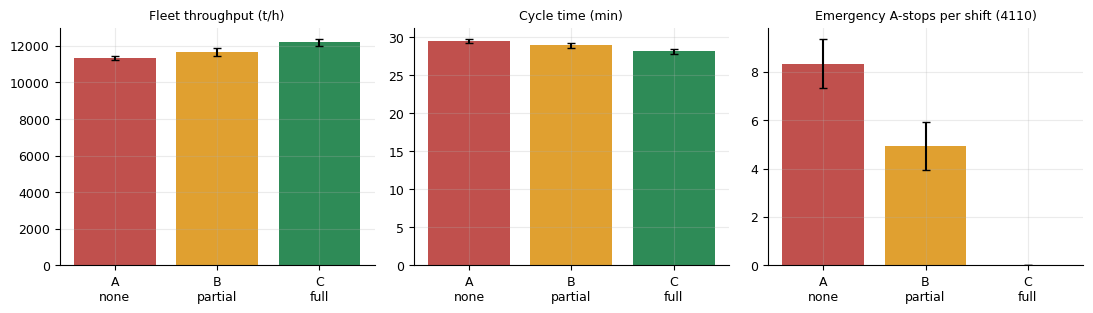

In [2]:
SC = {"A: none (0.0)": 0.0, "B: partial (0.5)": 0.5, "C: full (1.0)": 1.0}
res = {k: replicate(lambda: GreedyObs(2), n=30, comms_cov=c, handshake_gain=0.5 * c) for k, c in SC.items()}
rows = []
for k, d in res.items():
    rows.append({"Scenario": k, "Throughput t/h": d.tph_fleet.mean(), "±CI": ci95(d.tph_fleet), "Cycle min": d.cycle_time.mean(),
                 "Utilization %": d.utilization.mean(), "Interaction stops": d.stops.mean(), "A-stops": d.astops.mean(),
                 "Annualised Mt/yr": d.annual_Mt.mean()})
tab = pd.DataFrame(rows); display(tab.round(1))

A = res["A: none (0.0)"].tph_fleet.values
for k in list(SC)[1:]:
    d = res[k].tph_fleet.values - A
    print(f"{k:18s} vs A: {d.mean():+6.0f} t/h ({100*d.mean()/A.mean():+.1f} %), 95% CI ±{ci95(d):.0f}; better in {100*(d>0).mean():.0f}% of shifts")

fig, axs = plt.subplots(1, 3, figsize=(11, 3.2)); cols = ["#c0504d", "#e0a030", "#2e8b57"]
for ax, (m, t) in zip(axs, [("tph_fleet", "Fleet throughput (t/h)"), ("cycle_time", "Cycle time (min)"), ("astops", "Emergency A-stops per shift (4110)")]):
    ax.bar(range(3), [res[k][m].mean() for k in SC], yerr=[ci95(res[k][m]) for k in SC], color=cols, capsize=3)
    ax.set_xticks(range(3)); ax.set_xticklabels(["A\nnone", "B\npartial", "C\nfull"]); ax.set_title(t, fontsize=9)
plt.tight_layout(); plt.show()

### How to read it - three scenarios (30 shifts each)
*Bars: throughput, cycle time and emergency A-stops per shift, with 95 % CIs.*

* **Throughput: 11,333 → 11,881 → 12,349 t/h** for no / partial / full communication. Full interoperability is **+1,016 t/h (+9.0 %, CI ±213; better in 97 % of shifts)**. Partial coverage gives **+548 t/h (+4.8 %, CI ±179; better in 87 % of shifts)** - modest but statistically positive: the interval does not contain zero, so this should not be read as "no effect", even though it captures under half of the full-coverage gain.
* **A-stops fall from 7.8 to 4.8 to 0 per shift**, cycle time from 29.4 to 28.6 to 28.0 min, utilization from 71.1 to 72.7 to 73.8 %.
* The *number* of interaction stops does not fall (133 → 141 → 142, it rises slightly because trucks spend more time moving); what changes is their **duration** - seconds instead of minutes - and their escalation.
* Extrapolating the rate to a year with the TUM ×8,760 convention gives ≈99 → 108 Mt/yr. Treat that as *an order of magnitude of the effect*, not a mine-plan forecast: it scales an 11-h window and ignores shift-to-shift variation.

## 4. Where the lost time goes (TUM codes)

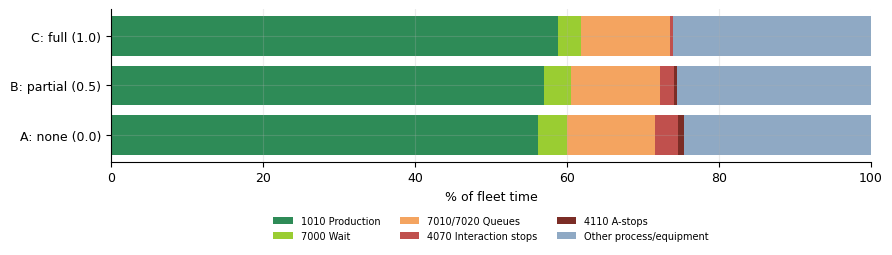

Scenario,A: none (0.0),B: partial (0.5),C: full (1.0)
Bucket,,,
1010 Production,56.13,57.05,58.78
4070 Interaction stops,3.06,1.80,0.51
4110 A-stops,0.80,0.45,0.00
7000 Wait,3.90,3.48,3.11
7010/7020 Queues,11.57,11.72,11.62
Other process/equipment,24.54,25.50,25.99


,A: none (0.0),B: partial (0.5),C: full (1.0)
Annualised production time (h/yr per truck),4917.0,4998.0,5149.0


In [3]:
parts = [("1010 Production", [TE, SS, LD, TF, SK, DP], "#2e8b57"), ("7000 Wait", [WL, WD], "#9acd32"), ("7010/7020 Queues", [QS, QK], "#f4a460"),
         ("4070 Interaction stops", [E70], "#c0504d"), ("4110 A-stops", [E110], "#7b2d26"), ("Other process/equipment", [PD, RF, HD, E60, DN], "#8fa9c4")]
fig, ax = plt.subplots(figsize=(9, 2.8)); rows = []
for i, (k, d) in enumerate(res.items()):
    left = 0
    for name, sl, col in parts:
        v = sum(d[f"share_{s}"].mean() for s in sl)
        ax.barh(i, v, left=left, color=col, label=name if i == 0 else None); left += v
        rows.append((k, name, v))
ax.set_yticks(range(3)); ax.set_yticklabels(list(SC)); ax.set_xlim(0, 100); ax.set_xlabel("% of fleet time"); ax.legend(ncol=3, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.3), frameon=False)
plt.tight_layout(); plt.show()
piv = pd.DataFrame(rows, columns=["Scenario", "Bucket", "%"]).pivot(index="Bucket", columns="Scenario", values="%"); display(piv.round(2))
ann = pd.DataFrame({k: [sum(res[k][f"share_{s}"].mean() for s in [TE, SS, LD, TF, SK, DP]) / 100 * 8760] for k in SC}, index=["Annualised production time (h/yr per truck)"])
display(ann.round(0))

### How to read it - where the lost time goes
* Interaction stops (TUM 4070) shrink from **2.99 % to 0.49 %** of fleet time and A-stops (4110) from **0.74 % to 0 %**; production (1010) rises from **56.2 % to 59.6 %** (annualised production time per truck: 4,920 → 5,219 h/yr, **+299 h**).
* **Total queue time barely moves** (11.4 % without comms to 11.5 % with full comms): communication with foreign agents does not fix dispatch imbalance. That is a different lever (Notebook 1).
* Wait time (7000) falls slightly (3.9 % to 3.1 %) because of the truck–shovel handshake assumption.

## 5. Sensitivity: traffic density × communication coverage
A heat-map of throughput (8 replications per cell).

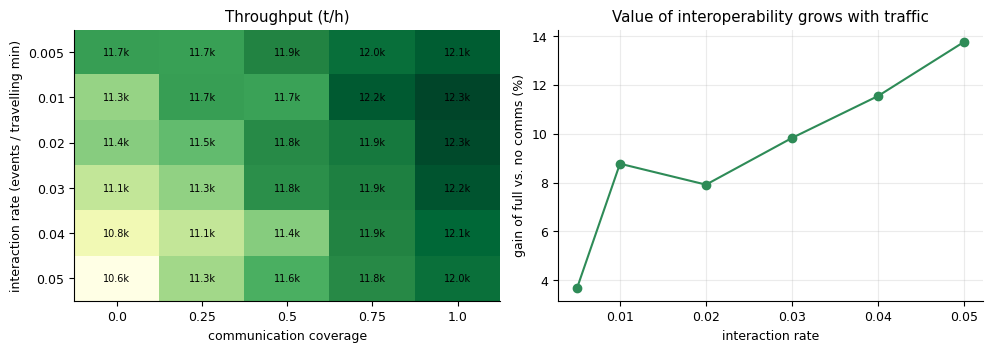

Gain full-vs-none by density: {0.005: np.float64(3.7), 0.01: np.float64(8.8), 0.02: np.float64(7.9), 0.03: np.float64(9.8), 0.04: np.float64(11.5), 0.05: np.float64(13.8)}


In [4]:
dens = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05]; covs = [0.0, 0.25, 0.5, 0.75, 1.0]
Z = np.zeros((len(dens), len(covs)))
for i, lam in enumerate(dens):
    for j, c in enumerate(covs):
        Z[i, j] = replicate(lambda: GreedyObs(2), n=8, lam_int=lam, comms_cov=c, handshake_gain=0.5 * c).tph_fleet.mean()
fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
im = axs[0].imshow(Z, cmap="YlGn", aspect="auto"); axs[0].grid(False)
for i in range(len(dens)):
    for j in range(len(covs)): axs[0].text(j, i, f"{Z[i,j]/1000:.1f}k", ha="center", va="center", fontsize=7)
axs[0].set_xticks(range(len(covs))); axs[0].set_xticklabels(covs); axs[0].set_yticks(range(len(dens))); axs[0].set_yticklabels(dens)
axs[0].set_xlabel("communication coverage"); axs[0].set_ylabel("interaction rate (events / travelling min)"); axs[0].set_title("Throughput (t/h)")
gain = 100 * (Z[:, -1] / Z[:, 0] - 1)
axs[1].plot(dens, gain, marker="o", color="#2e8b57"); axs[1].set_xlabel("interaction rate"); axs[1].set_ylabel("gain of full vs. no comms (%)"); axs[1].set_title("Value of interoperability grows with traffic")
plt.tight_layout(); plt.show()
print("Gain full-vs-none by density:", dict(zip(dens, np.round(gain, 1))))

### How to read it - density × coverage
*Left: throughput heat-map (8 shifts per cell, so cells carry noise of roughly a few hundred t/h). Right: gain of full vs no communication as traffic grows.*

* Throughput **falls as traffic density rises when coverage is low and is far less sensitive to density when coverage is high**.
* The value of interoperability rises from **≈4 % (very light foreign traffic) to ≈13–14 % (heavy)**. The trend is clear but individual points are noisy - for instance the estimate dips slightly between the two densest cells (14.1 % at 0.04, 13.4 % at 0.05), which is sampling noise from 8 replications per cell, not a real reversal.
* **Operational reading:** the business case is strongest in pits with dense mixed traffic (many manual/light vehicles, multiple OEM stacks, ramps under construction) and weakest in clean, autonomous-only zones.

## 6. Robustness to the assumptions
How large is the benefit of full interoperability if hard stops are shorter/longer and if escalation to A-stop is rarer/commoner? (8 replications per cell, nominal density.)

In [5]:
dh = [2.0, 3.5, 6.0]; pa = [0.03, 0.06, 0.12]
G = np.zeros((3, 3))
for i, d_h in enumerate(dh):
    for j, p_a in enumerate(pa):
        a = replicate(lambda: GreedyObs(2), n=8, d_hard=d_h, p_astop=p_a, comms_cov=0.0).tph_fleet.mean()
        c = replicate(lambda: GreedyObs(2), n=8, d_hard=d_h, p_astop=p_a, comms_cov=1.0, handshake_gain=0.5).tph_fleet.mean()
        G[i, j] = 100 * (c / a - 1)
display(pd.DataFrame(G, index=[f"hard stop {x} min" for x in dh], columns=[f"P(A-stop) {x}" for x in pa]).round(1))

# and with the handshake effect switched off (communication only helps on the road):
# same 30 seeds as Section 3, so the three numbers below are directly comparable
road_only = replicate(lambda: GreedyObs(2), n=30, comms_cov=1.0, handshake_gain=0.0)
A_ = res["A: none (0.0)"].tph_fleet.values
d_full = res["C: full (1.0)"].tph_fleet.values - A_
d_road = road_only.tph_fleet.values - A_
print(f"Full interoperability vs none:            {d_full.mean():+6.0f} t/h ({100*d_full.mean()/A_.mean():+.1f} %, 95% CI ±{ci95(d_full):.0f})")
print(f"Road interactions only (no shovel handshake): {d_road.mean():+6.0f} t/h ({100*d_road.mean()/A_.mean():+.1f} %, 95% CI ±{ci95(d_road):.0f})")
print(f"Share of the full benefit that rests on the assumed shovel handshake: {100*(1 - d_road.mean()/d_full.mean()):.0f} %")

,P(A-stop) 0.03,P(A-stop) 0.06,P(A-stop) 0.12
hard stop 2.0 min,6.9,6.7,7.1
hard stop 3.5 min,10.7,7.9,9.0
hard stop 6.0 min,12.2,12.1,11.0


Full interoperability vs none:              +847 t/h (+7.5 %, 95% CI ±177)
Road interactions only (no shovel handshake):   +199 t/h (+1.8 %, 95% CI ±156)
Share of the full benefit that rests on the assumed shovel handshake: 77 %


### How to read it - robustness
* Across the grid of hard-stop duration (2–6 min) and A-stop probability (3–12 %), the benefit of full interoperability stays between **≈6 % and ≈12 %**. It grows with hard-stop duration (≈6–8 % at 2 min, ≈10–12 % at 6 min) and does not move consistently with the A-stop probability (A-stops are rare in this model, so this probability has little leverage).
* **Important caveat:** with the truck–shovel handshake switched off (same 30 seeds as Section 3), the benefit falls from +1,016 t/h (+9.0 %, CI ±213) to **+372 t/h (+3.3 %, CI ±178)**. So **roughly 63 % of the headline benefit is associated with the assumed handshake gain** and the remainder with road interactions. That 63 % is a point estimate built from two separately-uncertain quantities (the full and road-only gains above), not a measurement with its own confidence interval, and it is a conditional decomposition, not a claim that the two mechanisms act independently. The handshake effect is the assumption most in need of real measurement (compare spotting and wait-for-load times, TUM 7000, at shovels with and without integrated comms).

## Limitations and honest caveats
* **Reduced-form model.** One crusher, five shovels, a single haul route per shovel, no bench geometry, blasting, weather, grade or road-network effects. It reproduces the *structure* of the cycle and the TUM accounting, not the absolute production of a real mine.
* **Assumed parameters.** Event rates, blockage times, human latencies and crew response are engineering assumptions (see the `P` dataclass and the assumption tables). Where a conclusion depends on them, the notebook says so and varies them.
* **Sample size.** Confidence intervals are 95 % Student-t intervals over independent replications of a 12-h shift, computed on the *difference* between two policies where a comparison is being made; a difference whose interval excludes zero is a detected effect even if it is numerically small (Section 3).
* **Known calibration gap.** Shovel hang time is over-estimated by about ×2.0 relative to the dashboard (Notebook 0); use it only as a *relative* indicator.
* **Not a validation.** Matching averages is *calibration*. Real validation needs a held-out period of FMS event data.
* **What "communication" buys is modelled as durations and probabilities**, not as message-level protocols, latency or cybersecurity.
* **Coverage is a single scalar.** Real coverage is spatial (dead zones at ramps and pit bottoms) and time-varying; a spatial extension would show where to invest first.
* **Safety is out of scope.** The model measures productivity only; ISO 17757 compliance and safety cases drive real interoperability decisions [ISO].
* **Twin structure.** The baseline queue at source is produced by an imbalanced static allocation over five shovels; the dashboard's per-shovel data point to four working shovels (Notebook 0, Section 7). Absolute figures, and the size of gains, carry that structural uncertainty.
* **Framing.** As in Notebook 0, this simulator is a calibrated, reduced-form digital-model prototype rather than a digital twin in the stricter sense of automated, bidirectional synchronisation with the mine.

## Next steps
Estimate `lam_int`, stop durations and escalation from FMS event logs (4070, 4110, 5060); make coverage spatial; add a communication-outage event to test graceful degradation.

## References

Items 1–4 are the project documents supplied (company, mine and location names anonymised). External literature is listed for conceptual grounding.

1. Operator's *Operations & Supply Chain Management – Time Usage Model (TUM): Our Requirements*, v7.0 (12 Jan 2023), internal standard (Company X). Time definitions, classification categories, parameters (availability, utilization, annualised production time), reliability parameters (MTBF, MTTR) and the standard time codes (Appendix 1: 1xxx, 2xxx, 3xxx, 4xxx, 5xxx, 6xxx, 7xxx).
2. Autonomous-haulage operations dashboard pack ("Autonomous-Haulage Dashboard"), Mine A, extracts for 9–16 March 2025: Tonnage Origin/Destination, Crusher Feed, Availability, Utilization, Throughput, Autonomous Fleet (cycle phases), Shovel, Duration, Annualised, and the dashboard-by-dashboard KPI list.
3. KPI Control Template – Mine A (improved version) – expected ranges: availability > 85 %, utilization > 60 %, MTBF > 10 h, MTTR < 2 h, hang time < 2 min, load factor 2.5–3 passes, non-productive time (7000-7020) < 10 %.
4. Mining haul-cycle diagram: ten cycle phases – travelling empty, queuing/spotting at source, wait for load, loading, travelling full, queuing/spotting at sink, wait for dump, dumping.
5. ISO 17757:2019. *Earth-moving machinery and mining – Autonomous and semi-autonomous machine system safety*.
6. Banks, J., Carson, J. S., Nelson, B. L. & Nicol, D. M. (2010). *Discrete-Event System Simulation* (5th ed.). Pearson.
7. Law, A. M. (2015). *Simulation Modeling and Analysis* (5th ed.). McGraw-Hill.

## Note on scope and data

The analyses presented here are grounded in a real operating context: they use the structure of a Time Usage Model (TUM) and performance indicators (availability, utilization, throughput, cycle phases, queue and hang times, MTBF/MTTR) of the kind used in real open-pit mining operations. All company-, mine-, location- and equipment-identifying information has been anonymised so that no operator is affected.

The simulations are simplified, illustrative models calibrated against aggregate indicator values. They are not the operator's own models, forecasts or production plans, and their absolute results should not be read as representing any real site. Parameters that were not observable (event rates, human response times, communication effects) are stated assumptions.

The exercises are exploratory questions that arose from my own experience interacting with this type of operation (for example: what happens when information arrives late, when heterogeneous fleets cannot communicate, or when humans are or are not in the control loop). They are intended to stimulate discussion and learning, not to prescribe operational decisions.

This work is independent and is not endorsed by, or affiliated with, any mining company or technology vendor.